In this exercise, we will use some geoprocessing techniques to estimate the population in the 2050 flood zone in Far Rockaway, QQueens. Using flood zone data as well as Census data, we will apportion population based on area before moving on to use a more granular estimate using MapPLUTO data. We will use API requests to get the data we need, and then use geospatial analysis techniques to estimate the population in the flood zone. We will also visualize our results using maps and charts.

By the end of the exercise, you should have a better understanding of how to use geoprocessing techniques to estimate population in a given area, as well as how to use different data sources to improve your estimates.

Throughout the course of the semester, we will be reusing functions that we define in previous exercises. Instead of copying and pasting these functions into each notebook, we will define them in a separate Python file and import them as needed. This way, we can keep our code organized and avoid duplication. The `cdptools` package reflects this- it is a folder in the repository that contains a `utils.py` file where we will define functions that we will use throughout the semester. We can then import these functions into our notebooks as needed. We can import the functions in `utils.py` within the `cdptools` package using the following code:


In [1]:
from cdptools import utils

We can then invoke the functions as shown below. This function, `set_axis_off()`, is a helper function that cleans up static map plots. You are encouraged to add additional functions that you create, or modify the functions in that folder, over the course of the semester as you see fit.

In [2]:
utils.set_axis_off()

We'll additionally need to import the other packages required for this tutorial.

In [3]:
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

## Preparing data

In [4]:
flood_zones_2050_gdf = gpd.read_file(
    "/Users/jaehyunlee/Desktop/GSAPP/2026_Summer/03_ARCHA4165_ Mapping Systems/data/Future Floodplain 2050s_20260603/geo_export_fab09dc5-c2ff-49b9-8f9b-e38e1f1a652f.shp"
).to_crs(epsg=2263)

A benefit of `geopandas` is that it makes it easy to read in geospatial data from a variety of formats, including GeoJSON, Shapefiles, and more. It also allows us to filter features based on attribute values (or bounding box) *before* importing, which makes the process more efficient, especially for large files. Below, we import Census block groups only in the 11691 zip code instead of the entire City. This is more efficient in terms of memory as well as saves us a step.

In [6]:
census_far_rockaway_gdf = gpd.read_file(
    "/Users/jaehyunlee/Documents/GitHub/cdp-mapping-systems/content/Data/census_nyc_sp.fgb", where="zip_code = '11691'"
)

We'll also use MapPLUTO to get parcel-level information for our area of interest. MapPLUTO is one of the most widely used and most complex datasets that describes the built environment in New York City. It contains information on land use, building characteristics, ownership, year built, and more for every tax lot in the City. We can use this data to get a more granular estimate of population in the flood zone by apportioning population based on residential units in each tax lot. The dataset is available for download as a shapefile [here](https://www.nyc.gov/content/planning/pages/resources/datasets/mappluto-pluto-change), however we can also access it via API endpoints, which is what we will do in this tutorial. We can access the data via API endpoints that allow us to filter by geographic area, which is more efficient than downloading the entire dataset and then filtering it in Python. Below, we will access MapPLUTO data for the 11691 zip code, which includes Far Rockaway.

ESRI ArcGIS-based API endpoints (which many governments use for their open data portals) have a query functionality that allows us to filter data before making requests. The [interface](https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query) allows for us to pass a number of query parameters to properly formulate our request. For our purposes, there are four parameters that are particularly important:
- `where`: this is where we can specify attribute-based filters. In our case, we will use this to filter for tax lots in the 11691 zip code.
- `outFields`: this is where we can specify which fields we want to get back in our response. This is important because it allows us to limit the amount of data we get back, which can make our request more efficient. In our case, we will specify that we want the `CD`, `LandUse`, `UnitsRes`, `BCTCB2020`, and `BCT2020` fields. Refer to the [data dictionary](https://s-media.nyc.gov/agencies/dcp/assets/files/pdf/data-tools/bytes/meta_mappluto.pdf) for more information on what these fields mean and how to interpret them.
- `resultOffset` and `resultRecordCount`: these parameters allow us to paginate our requests. This is important because some endpoints have limits on how much data they will return in a single request. By using these parameters, we can make multiple requests to get all the data we need. In our case, we will use these parameters to get all the tax lots in the 11691 zip code, which will require multiple requests if there are a lot of tax lots.
- `f`: this is where we can specify the format of our response. In our case, we will specify that we want the response in GeoJSON format, which is a common format for geospatial data and can be easily read into a GeoDataFrame using `geopandas`.

Each of these parameters are available in the GUI of the API endpoint, which can be helpful for formulating our request. Once we are satisfied with the request in the GUI, we can use those parameters to query the endpoint programmatically using the `requests` library in Python. Below is an example of how to use these parameters to query the MapPLUTO endpoint for tax lots in the 11691 zip code.

In [7]:
base_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query"
layer_wkid = 2263

all_features, offset = [], 0
while True:
    params = {
        "where": "ZipCode = 11691",
        "outFields": "CD,LandUse,UnitsRes,BCTCB2020,BCT2020",
        "returnGeometry": "true",
        "outSR": layer_wkid,
        "resultOffset": offset,
        "resultRecordCount": 2000,
        "f": "geojson",
    }
    r = requests.get(base_url, params=params)
    r.raise_for_status()
    fc = r.json()
    if "error" in fc:
        raise RuntimeError(fc["error"])
    feats = fc.get("features", [])
    all_features.extend(feats)
    if len(feats) < 2000:
        break
    offset += 2000

We can wrap the array of returned features as a geodataframe using the `from_features()` method in `geopandas`. We can assert the CRS as well, which will enable us to perform spatial operations below.

In [8]:
far_rockaway_pluto_gdf = gpd.GeoDataFrame.from_features(
    all_features, crs=f"EPSG:{layer_wkid}"
)

## Performing Proportional Split

Now that we have our data, we will attempt to answer a seemingly straightforward question: how many people live in the 2050 flood zone in Far Rockaway? There are a few different ways to approach this question, outside of being able to go to the place and count! One way is to use a technique called proportional split, which assumes that population is distributed evenly across a given area. We can use this technique to apportion population from Census block groups to the flood zone based on the area of overlap between the two. 

To illustrate this point, we can create a new field in our dataset that represents a point for every ten residents in each block group. Another function in our `utils.py` file, `random_points_in_geom()`, allows us to do just that. Hover over the function and click Cmd/Ctrl + click to read the function definition in the `utils.py` file. The map below shows what the theoretical even distribution of population across each census block group. While population varies across each block group, the distribution is even within each.

<Axes: >

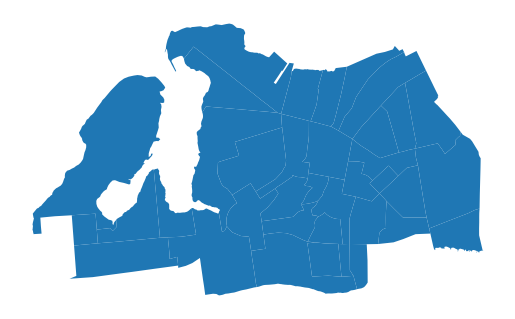

In [14]:
census_far_rockaway_gdf["pop_points"] = census_far_rockaway_gdf.apply(
    lambda row: utils.random_points_in_geom(
        row.geometry, row["Total Pop (Race/Ethnicity)"] / 10
    ),
    axis=1,
)

census_far_rockaway_gdf.plot()

Proportional split assumes that population is distributed evenly across a given area. This is almost never the case in practice; however, the simplicity of the method can provide a decent shorthand when other better data is not available. The map below shows what the theoretical even distribution of population across each census block group. While population varies across each block group, the distribution is even within each.

Text(0.5, 1.0, 'Randomly distributed population points in Far Rockaway')

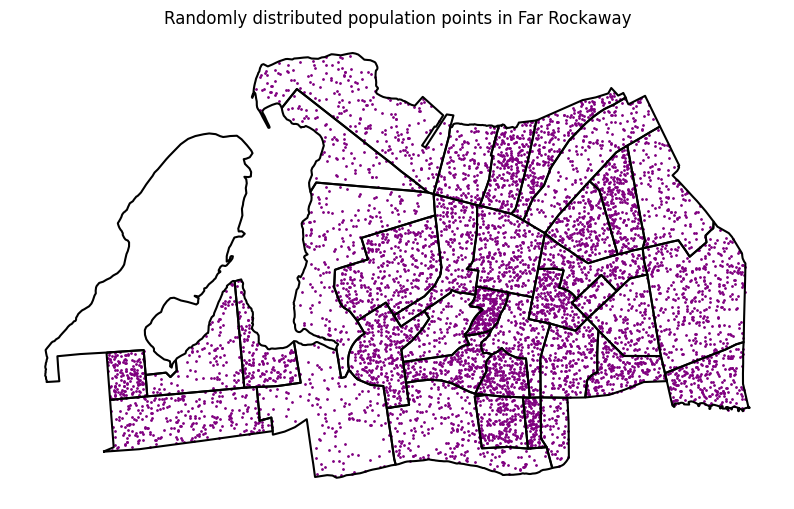

In [15]:
ax = census_far_rockaway_gdf.boundary.plot(color="black", figsize=(10, 10))
census_far_rockaway_gdf.set_geometry("pop_points").plot(
    ax=ax, color="purple", markersize=1
)
ax.set_title("Randomly distributed population points in Far Rockaway")

To be able to properly understand the relationship between residents and flood zones, we will need to overlay (in various ways) the flood zone data with Census data. There are four primary kinds of overlays offered in Geopandas: intersection, union, symmetrical difference, and difference (see the chart below). To frame our question in the context of flooding in Far Rockaway, we will use the intersection function to first get the flood zone polygons that intersect with our study area.

<img src="https://geopandas.org/en/v0.10.0/_images/overlay_operations.png" alt="Geopandas overlay operations" width="600"/>

*Source: QGIS Documentation via Geopandas docs*

In [16]:
flood_zone_in_study_area_gdf = gpd.overlay(
    census_far_rockaway_gdf, flood_zones_2050_gdf, how="intersection"
)

The resulting polygons represent the area of overlap between the census block groups and the flood zones. We can plot this to get a visual sense of how much of the study area is in the flood zone. You may notice some additional nuance here- there are different flood zones that represent different levels of risk (we can check the metadata [here](https://data.cityofnewyork.us/Environment/Future-Floodplain-2050s/27ya-gqtm/about_data)), and some block groups are only partially in the flood zone. This is where the proportional split technique comes in- we can apportion population to the flood zone based on the area of overlap between the two.

<Axes: >

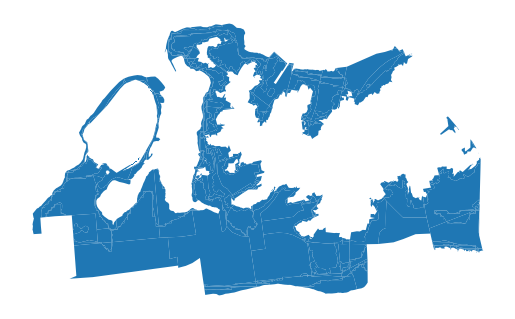

In [17]:
flood_zone_in_study_area_gdf.plot()

If we inspect the flood zones against the population points, we can see that some of the points fall within the flood zone, while others do not- or so the notion of population being evenly distributed across the block group would suggest. 

Text(0.5, 1.0, 'Randomly distributed population points in Far Rockaway')

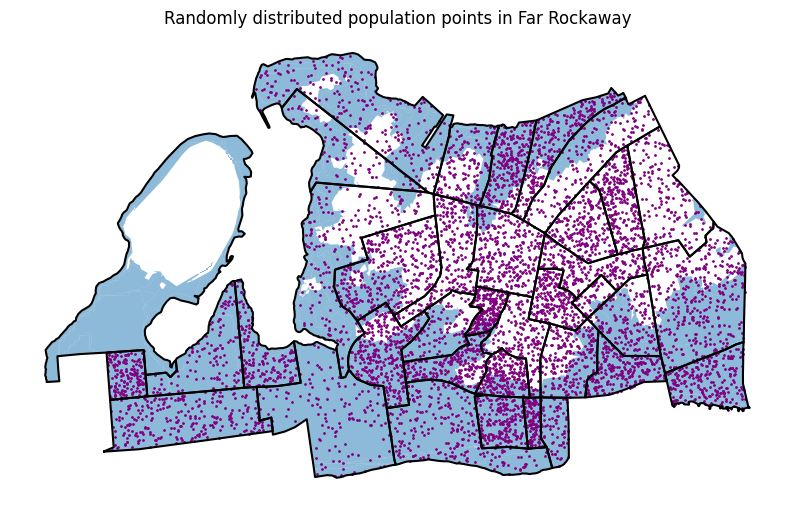

In [18]:
ax = flood_zone_in_study_area_gdf.plot(alpha=0.5, figsize=(10, 10))
census_far_rockaway_gdf.boundary.plot(color="black", figsize=(10, 10), ax=ax)
census_far_rockaway_gdf.set_geometry("pop_points").plot(
    ax=ax, color="purple", markersize=1
)
ax.set_title("Randomly distributed population points in Far Rockaway")

Now we'll apportion each census block group polygon to the flood zone based on the area of overlap between the two. To do so, we will:
- calculate the area of each census block group polygon
- calculate the area of overlap between each census block group polygon and the flood zone polygons by chaining together the `area` and `intersection()` functions in Geopandas on the `unioned` flood zone geodataframe we created above
- calculate the proportion of each census block group that is in the flood zone by dividing the area of overlap by the total area of the census block group
- apportion population to the flood zone by multiplying the total population of each census block group by the proportion of the block group that is in the flood zone.

In [19]:
# calculate the area of each census block group polygon
census_far_rockaway_gdf["bg_area"] = census_far_rockaway_gdf.geometry.area
# calculate the area of overlap
census_far_rockaway_gdf["flooded_area 2050"] = (
    census_far_rockaway_gdf.geometry.intersection(flood_zones_2050_gdf.union_all()).area
)
# calculate the proportion of each census block group that is in the flood zone
census_far_rockaway_gdf["frac_flooded_2050"] = (
    census_far_rockaway_gdf["flooded_area 2050"] / census_far_rockaway_gdf["bg_area"]
)

In [20]:
# apportion population based on percent overlap
census_far_rockaway_gdf["pop_in_flood_zone_2050"] = (
    census_far_rockaway_gdf["Total Pop (Race/Ethnicity)"]
    * census_far_rockaway_gdf["frac_flooded_2050"]
)

And now we can map the results- the map below shows the percent of the block group in the flood zone, confirming what our visual inspection above revealed.

<Axes: >

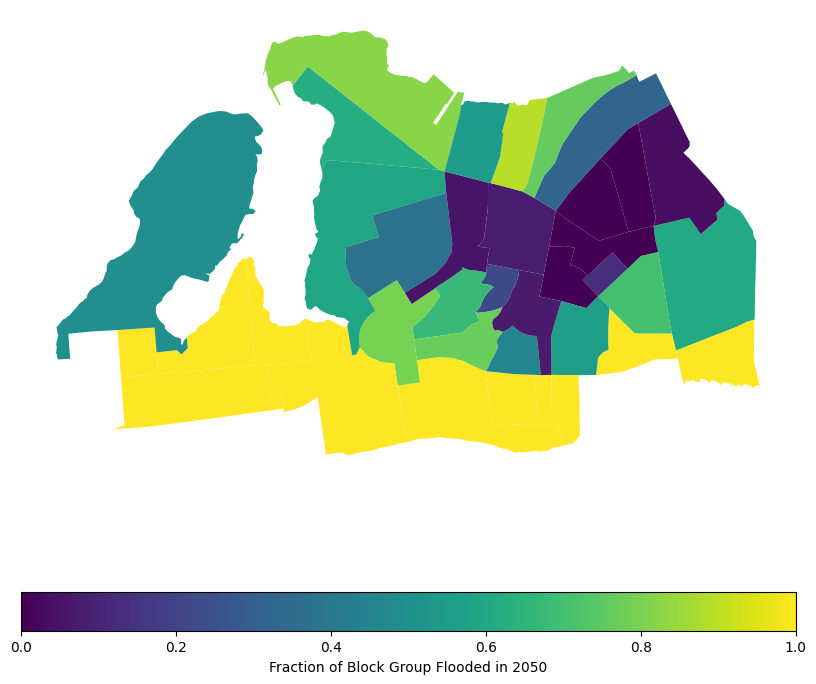

In [21]:
census_far_rockaway_gdf.plot(
    column="frac_flooded_2050",
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        "label": "Fraction of Block Group Flooded in 2050",
        "orientation": "horizontal",
    },
)

<Axes: >

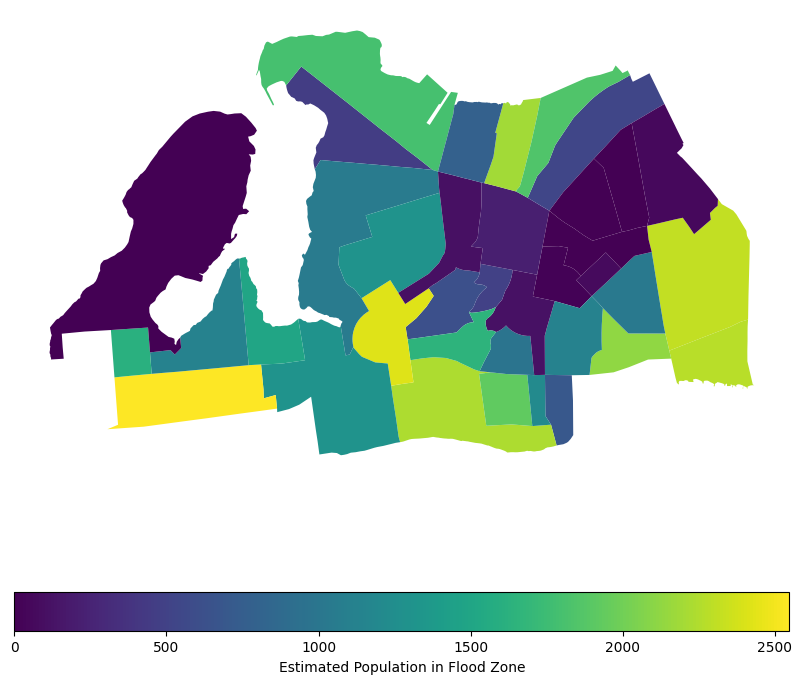

In [22]:
census_far_rockaway_gdf.plot(
    column="pop_in_flood_zone_2050",
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        "label": "Estimated Population in Flood Zone",
        "orientation": "horizontal",
    },
)

That representation does well to show the relative population density within each block group, assuming that the population in each is evenly distributed. Per our assumption on the proportional distribution, we would assume that the area coverage for each block group is proportional to the population, so the more area covered by a flood zone, the more population is affected. This is a common assumption in spatial analysis when we don't have more granular data on population distribution. However, it's important to note that this assumption may not always hold true, as population density can vary significantly within block groups, *especially* when dealing with dense urban areas. Luckily MapPLUTO indicates the number of residential units in each tax lot, so we can use that to apportion population more accurately.

To be able to properly apportion population to PLUTO lots, we'll need to ensure that they share an ID to perform an *attribute join*. We already know that the census data has a unique identifier for each block group, the `GISJOIN` field. MapPLUTO has a `BCT2020` and `BCTB2020` field- the census tract and the census block, but *not* the block group. We need to create a new field that splits the block field to get the block group.

To illustrate how this is possible, we can look at all block IDs for a given tract. In the below example, notice how each block starts with `4` (PLUTO's identifier for `Queens`) and then `103201`, the census tract ID. We can subset this field to extract the block group ID to match our census data using string slicing.

In [23]:
far_rockaway_pluto_gdf[far_rockaway_pluto_gdf.BCT2020 == "4103201"].BCTCB2020.unique()

<ArrowStringArray>
['41032013001', '41032013000', '41032013004', '41032013006', '41032013005',
 '41032012001', '41032012002', '41032012003', '41032011001', '41032011002',
 '41032011003', '41032012006', '41032012007', '41032012005', '41032012004',
 '41032011006', '41032011005', '41032011004', '41032013002', '41032013003',
 '41032012000']
Length: 21, dtype: str

Here we slice from the `1st` position to the `8th` position. Remember that in Python, string slicing is done using the syntax `string[start:stop]`, where `start` is the 0-based index of the first character to include and `stop` is the index of the first character to exclude. So in this case, we are including characters from index `1` to index `7`, which gives us the block group ID.

In [24]:
far_rockaway_pluto_gdf["block_group"] = far_rockaway_pluto_gdf["BCTCB2020"].str[1:8]

In [25]:
far_rockaway_pluto_gdf["block_group"].unique()

<ArrowStringArray>
['1032013', '1032021',       nan, '1032022', '1032023', '1032024', '1010031',
 '1010033', '1010021', '1010032', '1010042', '1010022', '1010043', '1010041',
 '0998013', '1010045', '1010044', '1032012', '1032011', '1008012', '1008011',
 '1008031', '1008032', '1008042', '1008041', '0992001', '0998012', '0998011',
 '0998015', '0998014', '0998021', '0998022', '0998023', '0992002', '0972041',
 '0972021', '0972061', '0972062', '0972071', '0972052']
Length: 40, dtype: str

We can similarly format the census block group ID in the census data to match the PLUTO block group ID. The census block group ID is the last 12 characters of the `GISJOIN` field, so we can slice the string to extract it.

In [26]:
census_far_rockaway_gdf["block_group"] = census_far_rockaway_gdf["GISJOIN"].str[8:]

Now we need to match the tax lots in MapPLUTO to the block groups in the census data on the new ID we created. We will apportion the population in each block group to the tax lots based on the number of residential units in each lot. This way, we can get a more accurate representation of how many people are affected by the flood zones, rather than assuming an even distribution across the block group.

In [27]:
def apportion_population_to_tax_lot(row, pluto_gdf, census_gdf):
    """Apportion population in a census block group to tax lots based on the number of residential units.
    returns the population per tax lot
    """
    block_group = row["block_group"]
    # get total pop from the census gdf
    if block_group not in census_gdf["block_group"].values:
        return 0
    population = census_gdf[census_gdf["block_group"] == block_group][
        "Total Pop (Race/Ethnicity)"
    ].values[0]
    # get just the pluto lots in the block group
    pluto_subset = pluto_gdf[pluto_gdf["block_group"] == block_group]
    # get total residential units in the block group
    total_units = pluto_subset["UnitsRes"].sum()
    if total_units == 0:
        return 0
    # apportion population to each tax lot based on the number of residential units
    row["pop_apportioned"] = row["UnitsRes"] / total_units * population
    return row["pop_apportioned"]

In [28]:
far_rockaway_pluto_gdf["est_pop_per_lot"] = far_rockaway_pluto_gdf.apply(
    lambda row: apportion_population_to_tax_lot(
        row, far_rockaway_pluto_gdf, census_far_rockaway_gdf
    ),
    axis=1,
)

<Axes: >

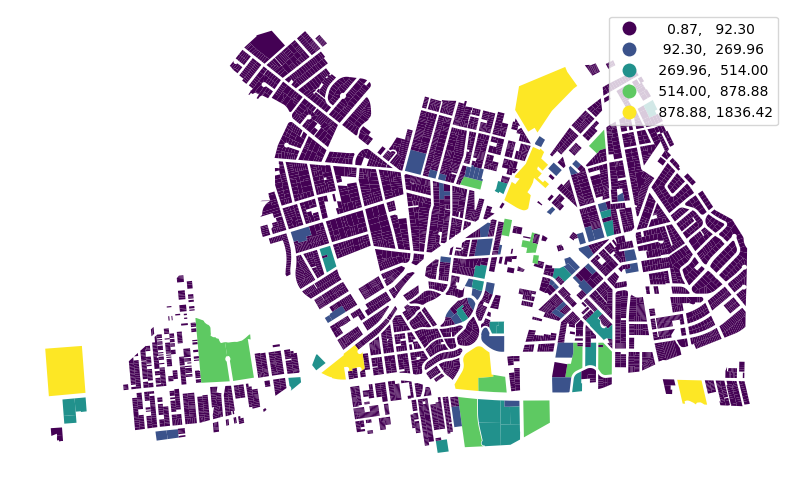

In [29]:
far_rockaway_pluto_gdf[far_rockaway_pluto_gdf.est_pop_per_lot.gt(0)].plot(
    column="est_pop_per_lot",
    legend=True,
    scheme="naturalbreaks",
    figsize=(10, 10),
)

Now we can apply the same random point distribution technique we used above, but instead to visualize at the tax lot level. We will make a dot for every two persons for lots with at least one resident.

In [30]:
far_rockaway_pluto_gdf["pop_points"] = far_rockaway_pluto_gdf.apply(
    lambda row: (
        utils.random_points_in_geom(row.geometry, row["est_pop_per_lot"] / 2)
        if row["est_pop_per_lot"] > 0
        else None
    ),
    axis=1,
)

<Axes: >

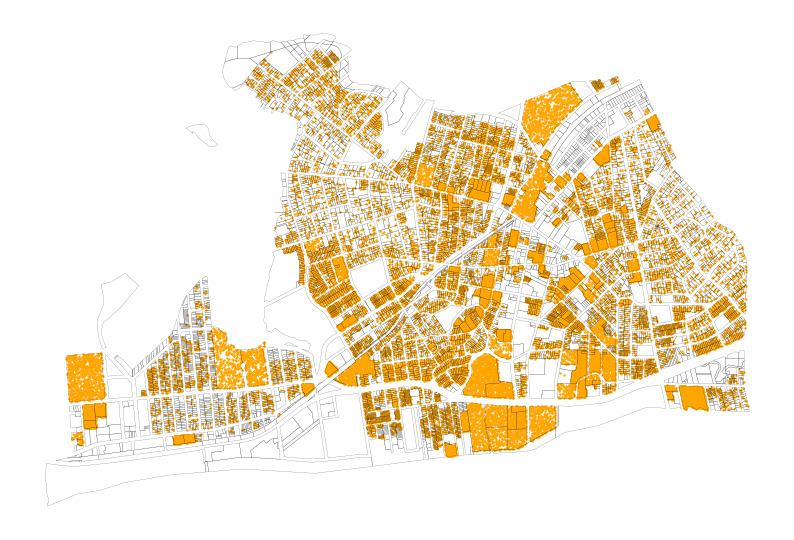

In [31]:
ax = far_rockaway_pluto_gdf.boundary.plot(
    color="black", linewidth=0.1, figsize=(10, 10)
)
far_rockaway_pluto_gdf.set_geometry("pop_points").plot(
    color="orange", markersize=0.5, legend=True, ax=ax
)

Now we have a much more precise view of where residents are located within the flood zones, which can help us better understand the potential impact of flooding on the community. We can see that certain areas within the flood zones have a higher concentration of residential units, which indicates that more people may be affected in those areas compared to others with fewer residential units. Now we can take another look at the residents in the flood zones, but this time with a more accurate representation of where people actually live, rather than just assuming an even distribution across the block groups.

In [32]:
flood_union = flood_zones_2050_gdf.union_all()

pluto_in_flood = far_rockaway_pluto_gdf.copy()
pluto_in_flood["lot_area"] = pluto_in_flood.geometry.area
pluto_in_flood["flooded_area"] = pluto_in_flood.geometry.intersection(flood_union).area
pluto_in_flood["frac_flooded"] = (
    pluto_in_flood["flooded_area"] / pluto_in_flood["lot_area"]
)

# Apportion estimated population in flood zone per lot
pluto_in_flood["est_pop_in_flood"] = (
    pluto_in_flood["est_pop_per_lot"] * pluto_in_flood["frac_flooded"]
)

# Group by block group to get total pop in flood zone per block group
bg_flood_pop = (
    pluto_in_flood.groupby("block_group")["est_pop_in_flood"]
    .sum()
    .reset_index()
    .rename(columns={"est_pop_in_flood": "bg_pop_in_flood_pluto"})
)

# Merge back to census block groups for comparison
census_far_rockaway_gdf = census_far_rockaway_gdf.merge(
    bg_flood_pop, on="block_group", how="left"
)
census_far_rockaway_gdf["bg_pop_in_flood_pluto"] = census_far_rockaway_gdf[
    "bg_pop_in_flood_pluto"
].fillna(0)

Text(0.5, 1.0, 'Estimated Population in 2050 Flood Zone per Block Group (PLUTO-weighted)')

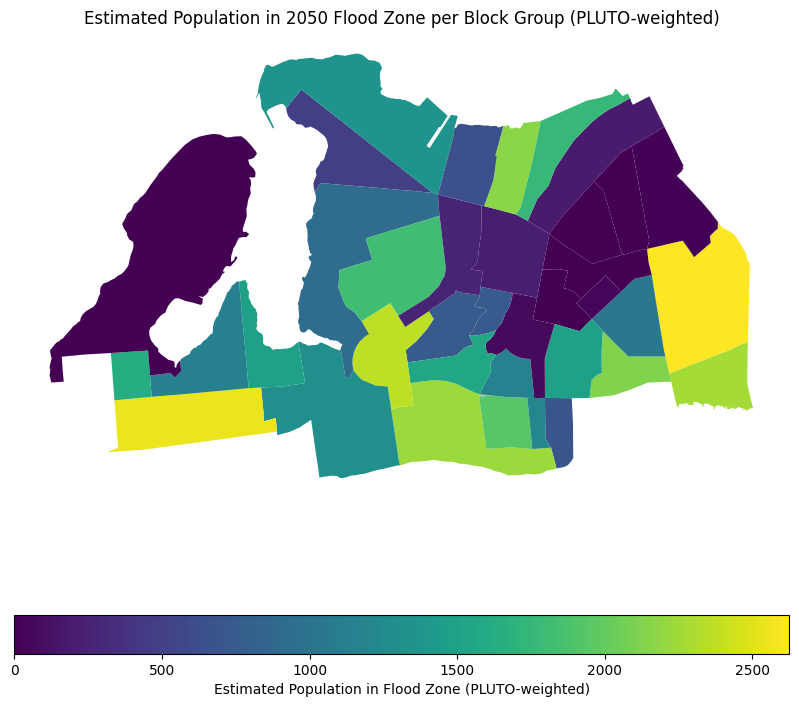

In [33]:
# Map the result
ax = census_far_rockaway_gdf.plot(
    column="bg_pop_in_flood_pluto",
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        "label": "Estimated Population in Flood Zone (PLUTO-weighted)",
        "orientation": "horizontal",
    },
)
ax.set_title("Estimated Population in 2050 Flood Zone per Block Group (PLUTO-weighted)")

In [34]:
# get the difference between the two estimates
census_far_rockaway_gdf["pop_diff"] = (
    census_far_rockaway_gdf["pop_in_flood_zone_2050"]
    - census_far_rockaway_gdf["bg_pop_in_flood_pluto"]
)

Now we can see the difference between the two estimates, which shows us how much our estimate of population in the flood zones has changed by using the proportional split method with MapPLUTO data. This can help us understand the potential impact of flooding on the community more accurately, and can inform better decision-making for flood mitigation and emergency response planning. The negative values in the difference map below indicate cases where the proportional split estimated fewer people in the flood zones compared to the even distribution method, while positive values indicate cases where the proportional split estimated more people in the flood zones. This highlights the importance of using more granular data and methods to get a more accurate picture of vulnerability to flooding.

<Axes: >

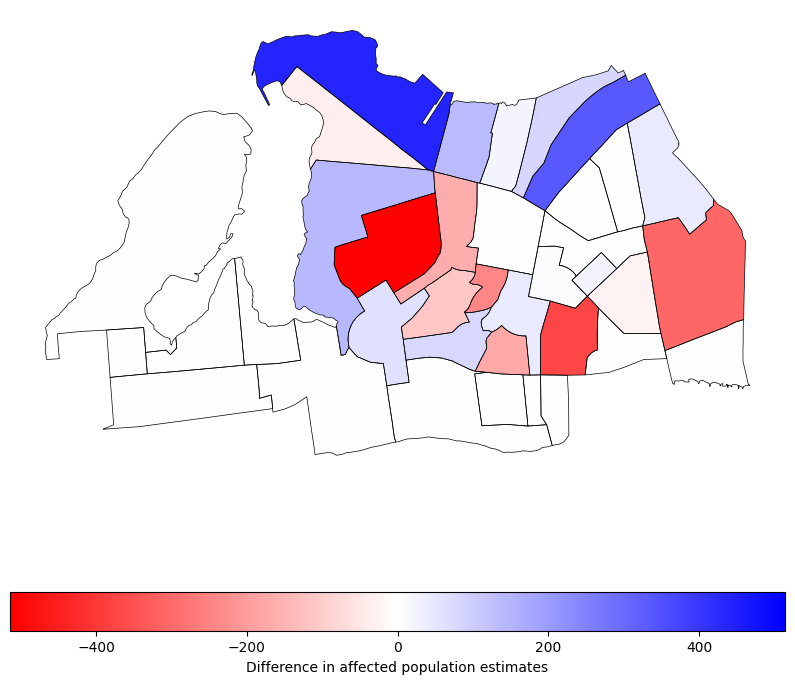

In [35]:
ax = census_far_rockaway_gdf.boundary.plot(
    edgecolor="black", figsize=(10, 10), linewidth=0.5
)
census_far_rockaway_gdf.plot(
    "pop_diff",
    legend=True,
    cmap="bwr_r",
    vmin=-census_far_rockaway_gdf["pop_diff"].abs().max(),
    vmax=census_far_rockaway_gdf["pop_diff"].abs().max(),
    legend_kwds={
        "label": "Difference in affected population estimates",
        "orientation": "horizontal",
    },
    ax=ax,
)